# Regressão Softmax com dados do MNIST

## Objetivo

O objetivo deste notebook é ilustrar o uso de praticamente a mesma rede desenvolvida para a classificação das flores Íris, porém agora com o problema de classificação de dígitos manuscritos utilizando o dataset MNIST.
As principais diferenças são:
- tipo do dado, agora imagem com muito atributos: 28 x 28 pixels
- número de amostras, muito maior, 60 mil
Neste exercício será possível a interpretação do significado dos parâmetros treinados

## Importação das bibliotecas

In [162]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from torch.autograd import Variable
import torch
import torchvision

## Carregamento dos dados do MNIST

In [163]:
! git clone https://github.com/vcasadei/MNIST.git

fatal: destination path 'MNIST' already exists and is not an empty directory.


In [164]:
dataset_dir = 'MNIST/'

x_train, y_train = torch.load(dataset_dir + 'processed/training.pt')

print("Amostras de treinamento:", x_train.size(0))

print("\nDimensões dos dados das imagens:   ", x_train.size())
print("Valores mínimo e máximo dos pixels:", torch.min(x_train), torch.max(x_train))
print("Tipo dos dados das imagens:        ", type(x_train))
print("Tipo das classes das imagens:      ", type(y_train))

Amostras de treinamento: 60000

Dimensões dos dados das imagens:    torch.Size([60000, 28, 28])
Valores mínimo e máximo dos pixels: tensor(0, dtype=torch.uint8) tensor(255, dtype=torch.uint8)
Tipo dos dados das imagens:         <class 'torch.Tensor'>
Tipo das classes das imagens:       <class 'torch.Tensor'>


In [165]:
x_train = x_train.float()

x_train = x_train / 255.

print("Amostras de treinamento:", x_train.size(0))

print("\nDimensões dos dados das imagens:   ", x_train.size())
print("Valores mínimo e máximo dos pixels:", torch.min(x_train), torch.max(x_train))
print("Tipo dos dados das imagens:        ", type(x_train))
print("Tipo das classes das imagens:      ", type(y_train))

Amostras de treinamento: 60000

Dimensões dos dados das imagens:    torch.Size([60000, 28, 28])
Valores mínimo e máximo dos pixels: tensor(0.) tensor(1.)
Tipo dos dados das imagens:         <class 'torch.Tensor'>
Tipo das classes das imagens:       <class 'torch.Tensor'>


In [166]:
from torch.utils.data import Dataset

class MNISTDataset(Dataset):
    def __init__(self, x_data, target):
        super(MNISTDataset, self).__init__()
        if (len(x_data) == len(target)):
          self.data = x_data.view(-1, 28*28)
          self.target = target
        else:
          raise IndexError('X and Y do not have the same number of items. X has {} and Y has {} values'.format(len(x_data), len(target)))

    def __len__(self):
      # ou return self.data.shape[0]
        return len(self.data)

    def __getitem__(self, index):
        if (index > len(self.data)):
            raise IndexError('Index out of range: Dataset has {} values and you tried to retrieve value {} which is out of range'.format(len(self.data), index))
        x = self.data[index]
        y = self.target[index]

        return (x, y)

In [167]:
dataset = MNISTDataset(x_train, y_train)

In [168]:
x, y = dataset[1]

In [169]:
y

tensor(0)

(np.float64(-0.5), np.float64(232.5), np.float64(87.5), np.float64(-0.5))

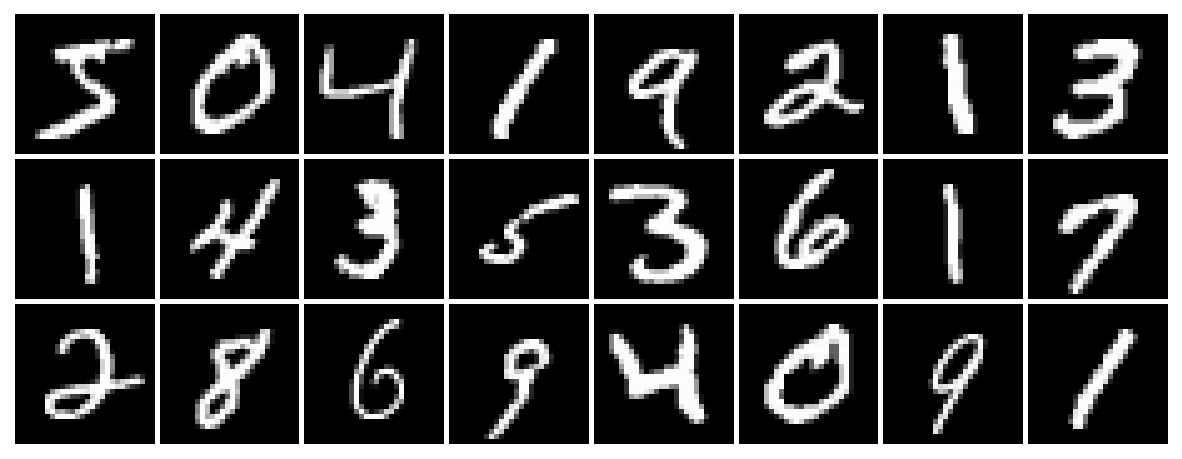

In [170]:
n_samples = 24

# cria um grid com as imagens
grid = torchvision.utils.make_grid(x_train[:n_samples].unsqueeze(1), pad_value=1.0, padding=1)

plt.figure(figsize=(15, 10))
plt.imshow(grid.numpy().transpose(1, 2, 0))
plt.axis('off')

### Visualizando uma imagem com o matplotlib

class: tensor(5)


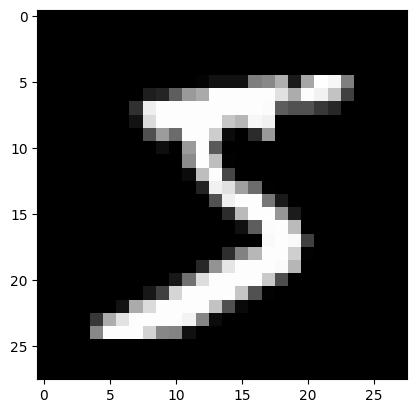

In [171]:
image  = x_train[0]
target = y_train[0]

plt.imshow(image.numpy().reshape(28,28), cmap='gray')
print('class:', target)

## Modelo

In [172]:
model = torch.nn.Linear(28*28, 10) # 28*28 atributos de entrada e 10 neurônios na sáida

### Testando um predict com poucas amostras

In [173]:
from torch.utils.data import random_split
train_dataset, val_dataset = random_split(dataset, [0.7, 0.3])

In [174]:
len(train_dataset)

42000

In [175]:
from torch.utils.data import DataLoader

train_data_loader = DataLoader(train_dataset,
                         batch_size=100, # tamanho do mini-batch de dados
                         shuffle=True) # se for True, embaralha os dados no inicio de cada iteração

In [176]:
from torch.utils.data import DataLoader

val_data_loader = DataLoader(val_dataset,
                         batch_size=100, # tamanho do mini-batch de dados
                         shuffle=False) # se for True, embaralha os dados no inicio de cada iteração

In [177]:
x, y = next(iter(train_data_loader))

In [178]:
x[1]

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0706,
        0.8000, 0.9686, 0.1098, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0118,
        0.4510, 0.9961, 0.8980, 0.0549, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 

In [179]:
model(x[1])

tensor([ 0.1515, -0.1270, -0.2492, -0.1153, -0.0625, -0.2699, -0.0386,  0.0293,
         0.3433,  0.0895], grad_fn=<ViewBackward0>)

## Treinamento

### Inicialização dos parâmetros

In [180]:
epochs = 10
learningRate = 0.5

# Utilizaremos CrossEntropyLoss como função de perda
criterion = torch.nn.CrossEntropyLoss()

# Gradiente descendente
optimizer = torch.optim.SGD(model.parameters(), lr=learningRate)

### Visualização do grafo computacional da perda (loss)

In [181]:
!pip install graphviz
!pip install git+https://github.com/szagoruyko/pytorchviz

  Cloning https://github.com/szagoruyko/pytorchviz to /tmp/pip-req-build-2h2lu7kt
  Running command git clone --filter=blob:none --quiet https://github.com/szagoruyko/pytorchviz /tmp/pip-req-build-2h2lu7kt
  Resolved https://github.com/szagoruyko/pytorchviz to commit 5cf04c13e601366f6b9cf5939b5af5144d55b887
  Preparing metadata (setup.py) ... done


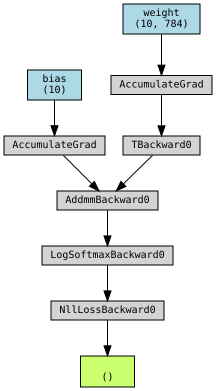

In [182]:
y_pred = model(Variable(x_train.view(-1,28*28)))
loss = criterion(y_pred, Variable(y_train))
from torchviz import make_dot, make_dot_from_trace
p = make_dot(loss, dict(model.named_parameters()))
p

### Laço de treinamento dos pesos

In [185]:
from IPython import display
import numpy
a = 10
losses = []
zs = []
fig = plt.figure(figsize=(18, 6))
train_acc_batch = []
val_acc_batch = []
train_acc_epoch = []
val_acc_epoch = []
train_loss_epoch = []
val_loss_epoch = []
val_loss_batch = []
train_loss_batch = []
train_best_acc_epoch = 0
val_best_acc_epoch = 0
train_best_loss_epoch = 100
val_best_loss_epoch = 100

try:
    for i in range(epochs):
        model.train()
        for (k, (x, y)) in enumerate(train_data_loader):
            # Predict da rede
            outputs = model(x)
            zs.append(outputs[1].detach().numpy())

            # calcula a perda
            loss = criterion(outputs, y)

            # zero, backpropagation, ajusta parâmetros pelo gradiente descendente
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss_batch.append(loss.data)
            _, predicts = torch.max(outputs, 1)

            y_pred = predicts.data
            accuracy = (y_pred.numpy() == y.numpy()).mean()
            train_acc_batch.append(accuracy)
            train_best_acc_epoch = max(train_best_acc_epoch, accuracy)
            train_best_loss_epoch = min(train_best_loss_epoch, loss.data)
        train_loss_epoch.append(train_best_loss_epoch)
        train_acc_epoch.append(train_best_acc_epoch)

        # evaluation
        model.eval()

        with torch.no_grad():
            for (x_val, y_val) in val_data_loader:
                val_pred = model(x_val)
                loss = criterion(val_pred, y_val)

                val_loss_batch.append(loss)

                _, val_predicts = torch.max(val_pred, 1)
                y_val_pred = val_predicts.data
                accuracy = (y_val_pred.numpy() == y_val.numpy()).mean()

                val_acc_batch.append(accuracy)
                val_best_acc_epoch = max(val_best_acc_epoch, accuracy)
                val_best_loss_epoch = min(val_best_loss_epoch, loss.data)
            val_loss_epoch.append(val_best_loss_epoch)
            val_acc_epoch.append(val_best_acc_epoch)

except KeyboardInterrupt:
    pass

<Figure size 1800x600 with 0 Axes>

In [43]:
model.weight.grad

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

In [44]:
print('Final loss:', loss.data)

Final loss: tensor(0.2673)


### Visualizando gráfico de perda durante o treinamento

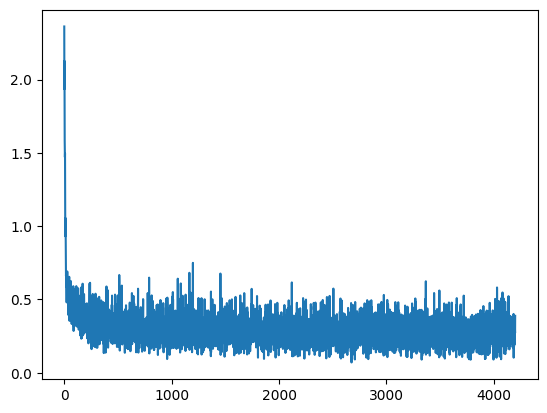

In [186]:
plt.plot(train_loss_batch)

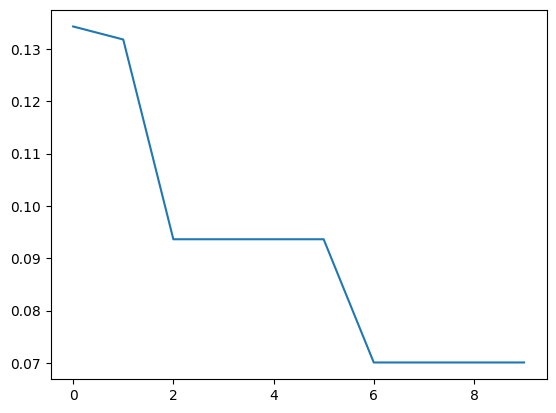

In [187]:
plt.plot(train_loss_epoch)

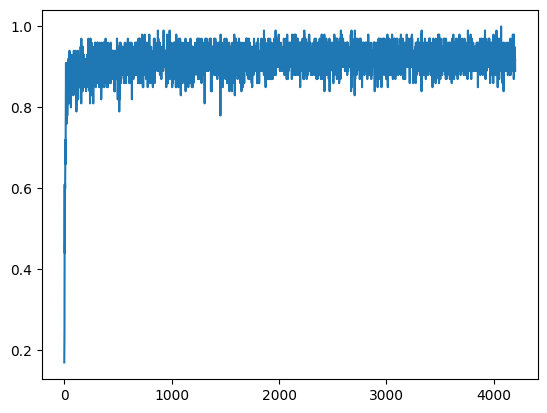

In [188]:
plt.plot(train_acc_batch)

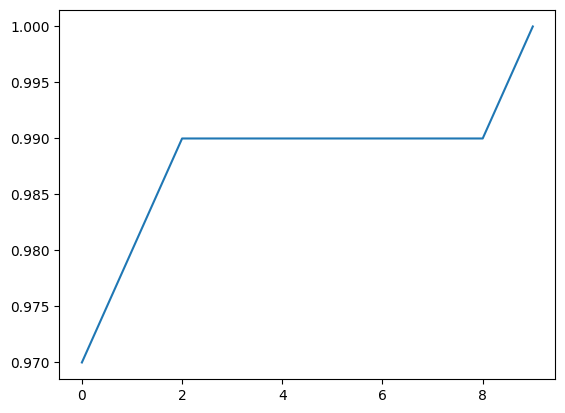

In [189]:
plt.plot(train_acc_epoch)

Gráfico de épocas salvo como 'epoch_comparison.png'


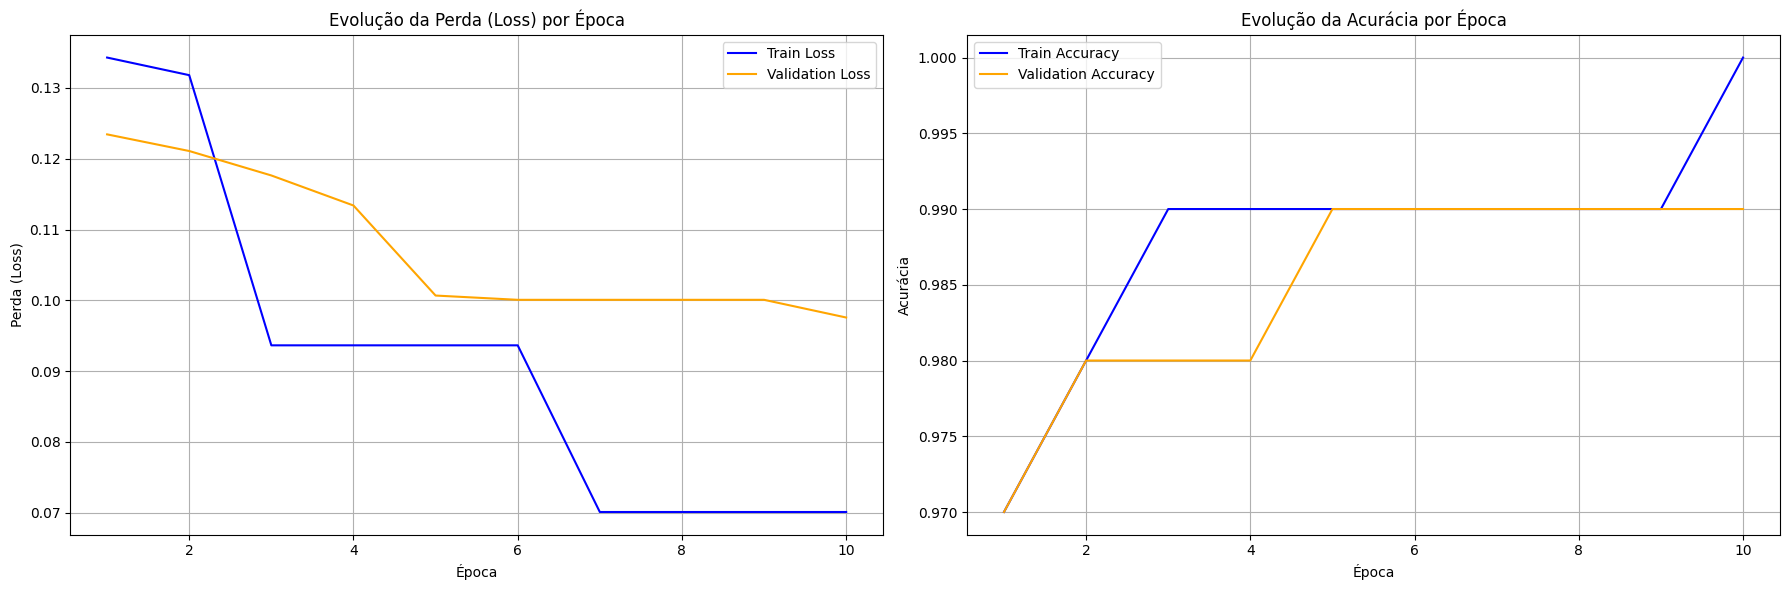

In [190]:
import matplotlib.pyplot as plt
import numpy as np

# Cria o eixo X (número de épocas)
epoch_list = list(range(1, len(train_loss_epoch) + 1))

# Cria uma figura com 2 subplots (1 linha, 2 colunas)
plt.figure(figsize=(18, 6))

# --- Gráfico 1: Perda (Loss) por Época ---
plt.subplot(1, 2, 1) # (linhas, colunas, índice)
plt.plot(epoch_list, train_loss_epoch, label='Train Loss', color='blue')
plt.plot(epoch_list, val_loss_epoch, label='Validation Loss', color='orange')
plt.title('Evolução da Perda (Loss) por Época')
plt.xlabel('Época')
plt.ylabel('Perda (Loss)')
plt.legend()
plt.grid(True)

# --- Gráfico 2: Acurácia por Época ---
plt.subplot(1, 2, 2) # (linhas, colunas, índice)
plt.plot(epoch_list, train_acc_epoch, label='Train Accuracy', color='blue')
plt.plot(epoch_list, val_acc_epoch, label='Validation Accuracy', color='orange')
plt.title('Evolução da Acurácia por Época')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)

plt.tight_layout() # Ajusta os plots para não sobrepor
plt.savefig('epoch_comparison.png')
print("Gráfico de épocas salvo como 'epoch_comparison.png'")
# plt.show() # Descomente se estiver rodando localmente

Gráfico de batches salvo como 'batch_analysis.png'


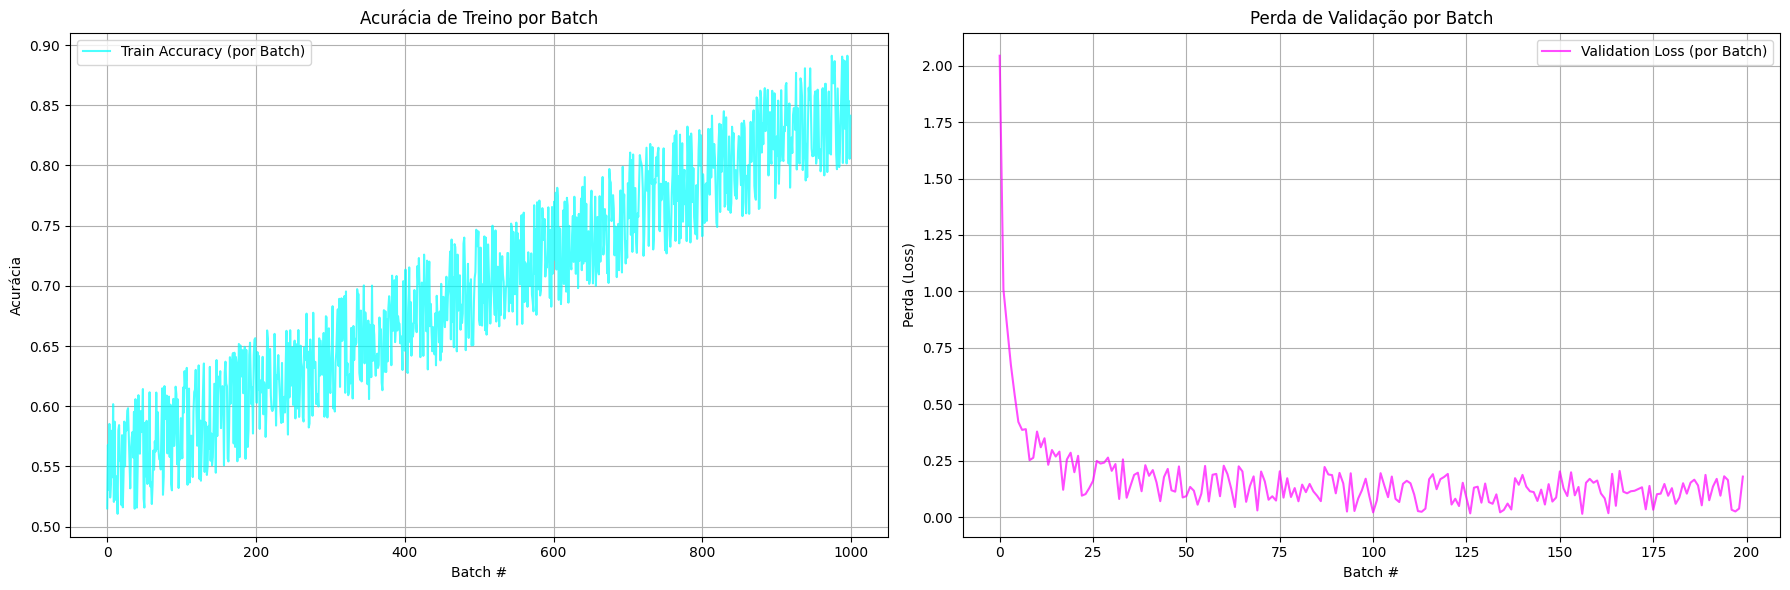

In [191]:
import matplotlib.pyplot as plt
import numpy as np

# --- Dados de Exemplo (substitua pelas suas listas) ---
# (Assumindo 1000 batches de treino e 200 de validação no total)
total_train_batches = 1000
total_val_batches = 200

# (Suas listas 'train_acc_batch' e 'val_loss_batch' que você mencionou)
train_acc_batch = [0.5 + (i * 0.0003) + np.random.rand() * 0.1 for i in range(total_train_batches)]
val_loss_batch = [2.0 / (i + 1) + np.random.rand() * 0.2 for i in range(total_val_batches)]
# --------------------------------------------------------

# Cria uma figura com 2 subplots
plt.figure(figsize=(18, 6))

# --- Gráfico 1: Acurácia de Treino por Batch ---
plt.subplot(1, 2, 1)
plt.plot(train_acc_batch, label='Train Accuracy (por Batch)', color='cyan', alpha=0.7)
plt.title('Acurácia de Treino por Batch')
plt.xlabel('Batch #')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)

# --- Gráfico 2: Perda de Validação por Batch ---
plt.subplot(1, 2, 2)
plt.plot(val_loss_batch, label='Validation Loss (por Batch)', color='magenta', alpha=0.7)
plt.title('Perda de Validação por Batch')
plt.xlabel('Batch #')
plt.ylabel('Perda (Loss)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('batch_analysis.png')
print("Gráfico de batches salvo como 'batch_analysis.png'")
# plt.show() # Descomente se estiver rodando localmente

## Avaliação

### Acurácia tanto no conjunto de treinamento como no conjunto de testes

In [15]:
def predict(model, input_data):
    outputs = model(Variable(input_data))
    _, predicts = torch.max(outputs, 1)

    return predicts.data

y_pred = predict(model, x_train.view(-1, 28*28))
accuracy = (y_pred.numpy() == y_train.numpy()).mean()
print('Accuracy:', accuracy)

Accuracy: 0.823


### Matriz de confusão com dados de treinamento e teste

In [16]:
print('Matriz de confusão:')
pd.crosstab(y_pred.numpy(), y_train.numpy())

Matriz de confusão:


col_0,0,1,2,3,4,5,6,7,8,9
row_0,,,,,,,,,,
0,93,0,4,1,1,3,3,1,0,2
1,0,108,10,1,1,3,3,6,6,3
2,2,1,75,0,0,2,2,1,3,3
3,0,1,0,80,0,15,0,0,8,2
4,0,0,2,0,91,6,1,2,0,5
5,0,1,0,3,0,52,1,0,3,1
6,2,1,1,2,3,3,84,0,0,1
7,0,1,4,3,2,1,0,103,0,10
8,0,3,2,2,0,4,0,0,64,0


## Visualizando a matriz de pesos treinados

Observe que a matriz de peso treinado para cada classe mostra a importância dos pesos associados aos caracteres de cada classe.

weights: torch.Size([10, 784])
bias:    torch.Size([10])


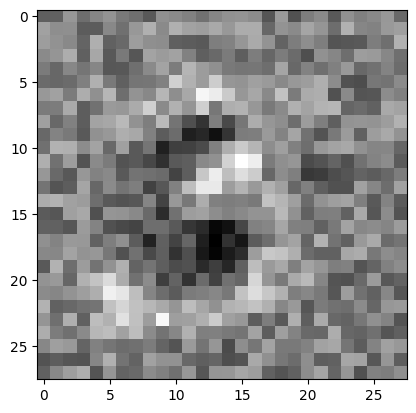

In [17]:
weights = model.state_dict()['weight']
print('weights:', weights.shape)

bias = model.state_dict()['bias']
print('bias:   ', bias.shape)

# Visualizando pesos da classe 3
plt.imshow(weights[3, :].numpy().reshape((28,28)),cmap = 'gray')
plt.show()

### Visualizando os pesos de todas as classes

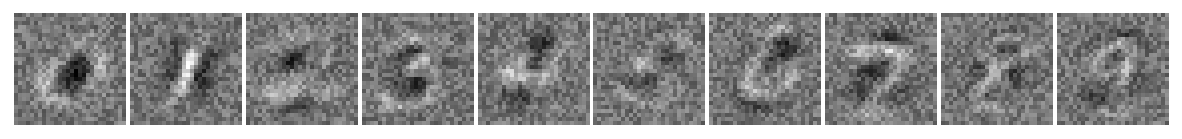

In [18]:
# cria um grid com as imagens
grid = torchvision.utils.make_grid(weights.view(-1, 1, 28, 28), normalize=True, pad_value=1.0, padding=1, nrow=10)

plt.figure(figsize=(15, 10))
plt.imshow(grid.numpy().transpose(1, 2, 0))
plt.axis('off');

### Diagrama da regressão softmax com visualização dos pesos W

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/RegressaoSoftmaxArgmaxNMIST.png)

# Atividades

## Exercícios

- 1) Insira código no laço do treinamento para que no final de cada época,
     seja impresso: o número da época e a perda e a acurácia

- 2) Insira código no laço do treinamento para visualização dos valores dos gradientes referentes à classe do dígito 4, no final de cada época.

<details>
<summary>Mostrar Resultado</summary>

```python
from IPython import display
import numpy
a = 5
losses = []
zs = []
fig = plt.figure(figsize=(18, 6))

try:
    for i in range(epochs):
        # Transforma a entrada para uma dimensão
        inputs = Variable(x_train.view(-1, 28 * 28))
        # Predict da rede
        outputs = model(inputs)
        zs.append(outputs[1].detach().numpy())

        # calcula a perda
        loss = criterion(outputs, Variable(y_train))

        # zero, backpropagation, ajusta parâmetros pelo gradiente descendente
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.data)
        weights_d = model.weight.data[4].numpy().reshape(28,28)
        weights_g = model.weight.grad.data[4].numpy().reshape(28,28)
        ww = np.concatenate((weights_d,weights_g),1)
        plt.imshow(ww.reshape((28,28*2)),cmap = 'gray')
        display.display(fig)
        display.clear_output(wait=True)
        input(i)
        
        _, predicts = torch.max(outputs, 1)

        y_pred = predicts.data
        accuracy = (y_pred.numpy() == y_train.numpy()).mean()
        print('Accuracy:', accuracy)
        print("epoca: " + str(i + 1))
        print("perda: " + str(loss.data.detach().numpy()))
except KeyboardInterrupt:
    pass
```

</details>



## Perguntas

1. Qual é o shape da matriz de entrada na rede?
2. Qual é o shape da saída da rede?
3. Qual é o número total de parâmetros da rede, incluindo o bias?

# Aprendizados
